# 12RE - Reducción de Dimensionalidad: Soluciones y Ejercicios Resueltos

Este notebook contiene las soluciones y código de ejemplo para los ejercicios propuestos en el punto 5 del módulo de Reducción de Dimensionalidad. Se incluyen además ejercicios adicionales con los datasets `wine` y `diabetes`.

Objetivos rápidos:
- Resolver los ejercicios propuestos (PCA en Iris, K-Means sobre reducciones de Digits).
- Añadir ejercicios/resoluciones para `wine` y `diabetes`.
- Incluir métricas y visualizaciones reproducibles (PCA, t-SNE, UMAP cuando esté disponible, KMeans, silhouette, ARI).

In [8]:
# Imports y comprobaciones iniciales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Importar librerías de machine learning
from sklearn.datasets import load_iris, load_digits, load_wine, load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('UMAP no está instalado. Para usarlo: pip install umap-learn')

sns.set_style('whitegrid')
# %matplotlib inline

## Ejercicio 1: PCA en Iris (2 componentes) - solución
Aplicar PCA al dataset `iris` para reducir de 4 a 2 dimensiones. Visualizar el resultado y comparar (colorear por especie).

Dimensiones originales: (150, 4)
Dimensiones tras PCA: (150, 2)
Varianza explicada (fractions): [0.73  0.229]


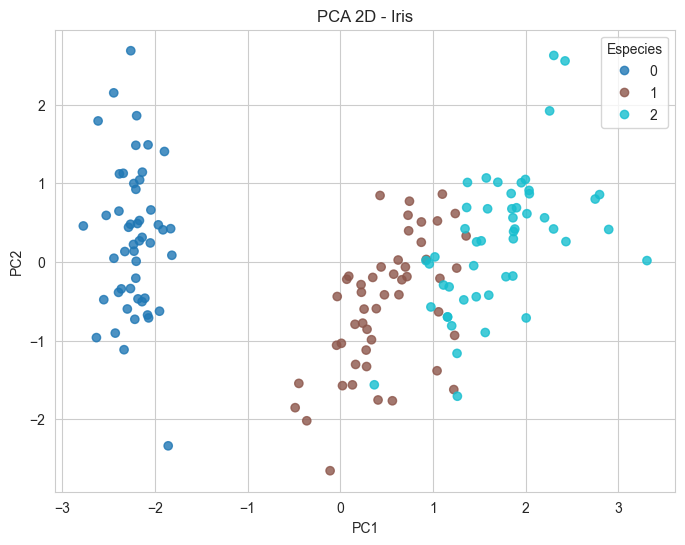

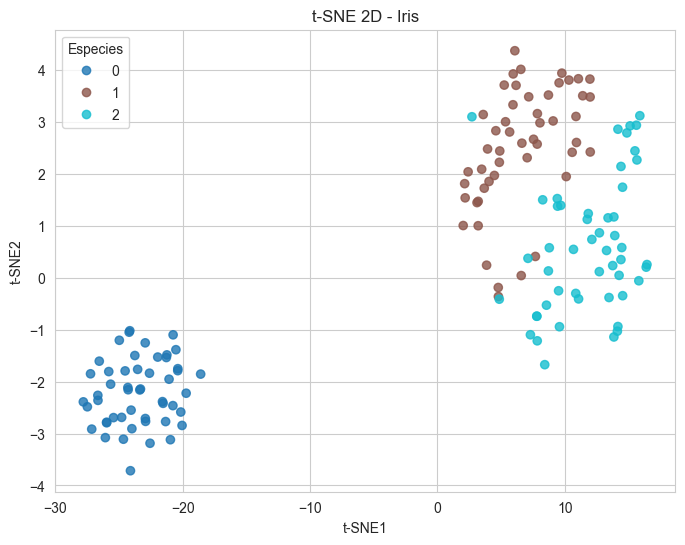

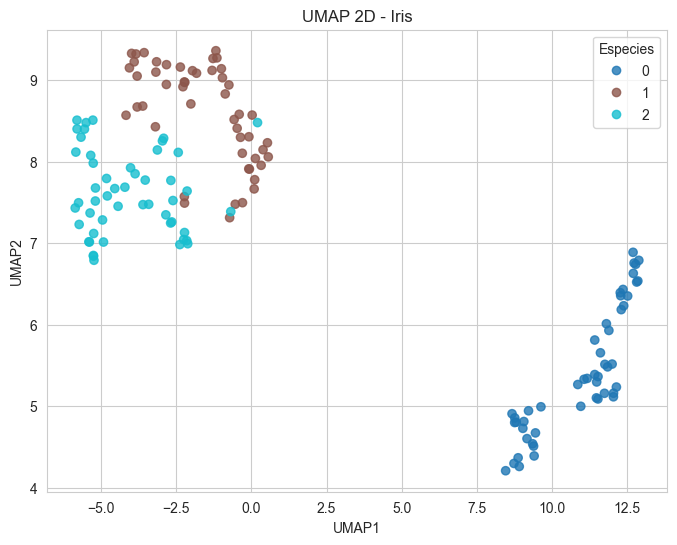

Adjusted Rand Index (k-Means en UMAP): 0.453
Silhouette Score (k-Means en UMAP): 0.765


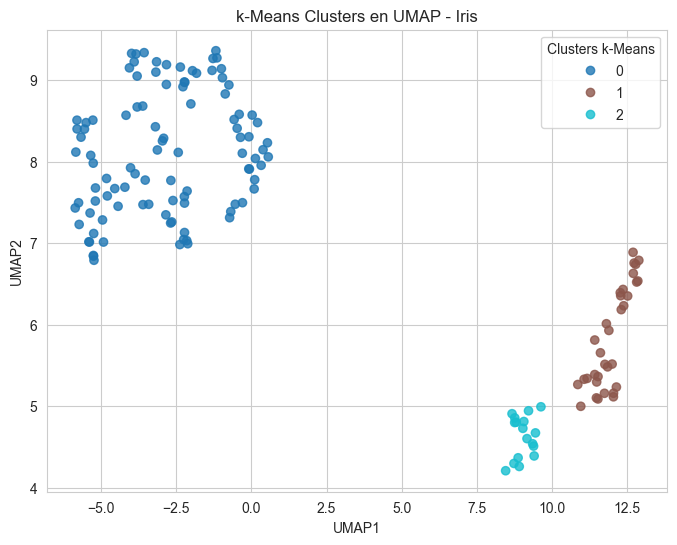

Adjusted Rand Index (Agglomerative en UMAP): 0.591
Silhouette Score (Agglomerative en UMAP): 0.615


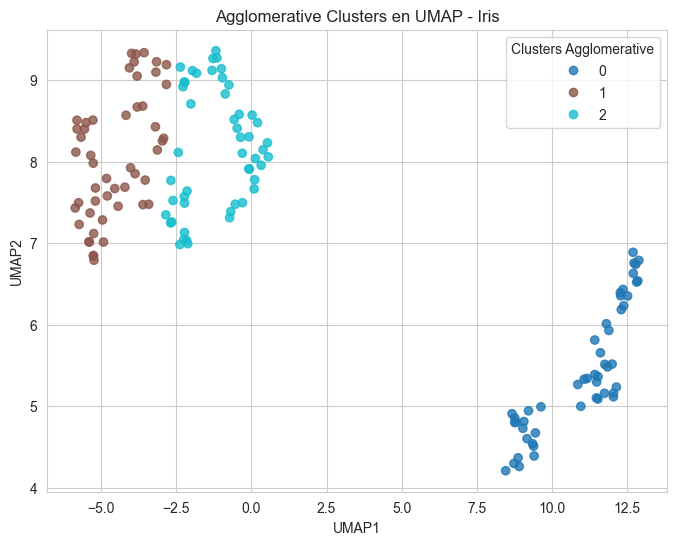

Adjusted Rand Index (DBSCAN en UMAP): 0.781
Silhouette Score (DBSCAN en UMAP): 0.491


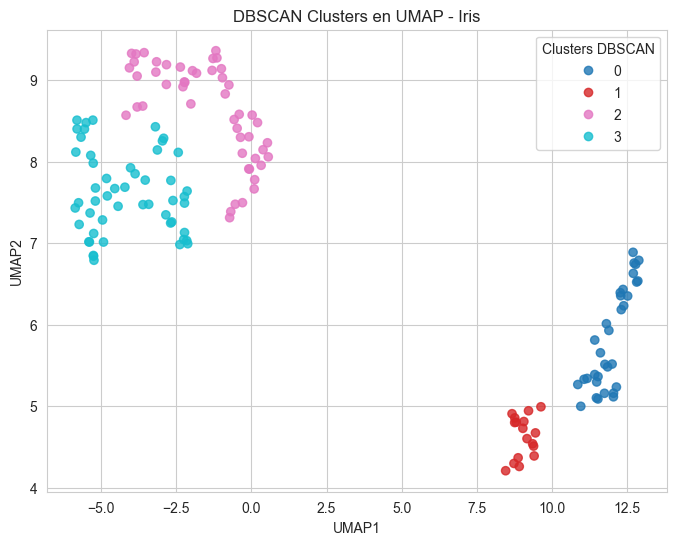

In [9]:
# Cargar Iris y hacer PCA 2D
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names
X_iris_scaled = StandardScaler().fit_transform(X_iris) # Estandarizamos
pca_iris = PCA(n_components=2, random_state=42) # PCA a 2D
X_iris_pca = pca_iris.fit_transform(X_iris_scaled) # Datos reducidos

print('Dimensiones originales:', X_iris.shape)
print('Dimensiones tras PCA:', X_iris_pca.shape)
print('Varianza explicada (fractions):', np.round(pca_iris.explained_variance_ratio_, 3))

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_iris_pca[:,0], X_iris_pca[:,1], c=y_iris, cmap='tab10', alpha=0.8)
plt.title('PCA 2D - Iris')
plt.xlabel('PC1')
plt.ylabel('PC2')
# Leyenda robusta para clases
plt.legend(*scatter.legend_elements(), title='Especies')
plt.show()

# t-SNE a iris
tsne_iris = TSNE(n_components=2, perplexity=30, random_state=42) # Instanciamos t-SNE
X_iris_tsne = tsne_iris.fit_transform(X_iris_scaled) # Aplicamos t-SNE

# Visualizamos los resultados
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_iris_tsne[:,0], X_iris_tsne[:,1], c=y_iris, cmap='tab10', alpha=0.8)
plt.title('t-SNE 2D - Iris')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
# Leyenda robusta para clases
plt.legend(*scatter.legend_elements(), title='Especies')
plt.show()

# UMAP a iris (si está disponible)
if UMAP_AVAILABLE:
    umap_reducer_iris = umap.UMAP(n_components=2, random_state=42) # Instanciamos UMAP
    X_iris_umap = umap_reducer_iris.fit_transform(X_iris_scaled) # Aplicamos UMAP

    # Visualizamos los resultados
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_iris_umap[:,0], X_iris_umap[:,1], c=y_iris, cmap='tab10', alpha=0.8)
    plt.title('UMAP 2D - Iris')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clases
    plt.legend(*scatter.legend_elements(), title='Especies')
    plt.show()

    # k-Means en UMAP
    kmeans_umap = KMeans(n_clusters=3, random_state=42)
    y_umap_kmeans = kmeans_umap.fit_predict(X_iris_umap)
    ari_umap = adjusted_rand_score(y_iris, y_umap_kmeans)
    print(f'Adjusted Rand Index (k-Means en UMAP): {ari_umap:.3f}')
    # Silhouette Score
    sil_umap = silhouette_score(X_iris_umap, y_umap_kmeans)
    print(f'Silhouette Score (k-Means en UMAP): {sil_umap:.3f}')

    # Visualizamos clusters k-Means en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_iris_umap[:,0], X_iris_umap[:,1], c=y_umap_kmeans, cmap='tab10', alpha=0.8)
    plt.title('k-Means Clusters en UMAP - Iris')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters k-Means')
    plt.show()

    # Clustering jerarquico en UMAP
    from sklearn.cluster import AgglomerativeClustering
    agglo_umap = AgglomerativeClustering(n_clusters=3, linkage='complete')
    y_umap_agglo = agglo_umap.fit_predict(X_iris_umap)
    ari_agglo = adjusted_rand_score(y_iris, y_umap_agglo)
    print(f'Adjusted Rand Index (Agglomerative en UMAP): {ari_agglo:.3f}')
    # Silhouette Score
    sil_agglo = silhouette_score(X_iris_umap, y_umap_agglo)
    print(f'Silhouette Score (Agglomerative en UMAP): {sil_agglo:.3f}')
# Visualizar clusters con clustering jerárquico en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_iris_umap[:,0], X_iris_umap[:,1], c=y_umap_agglo, cmap='tab10', alpha=0.8)
    plt.title('Agglomerative Clusters en UMAP - Iris')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters Agglomerative')
    plt.show()

    # DBSCAN en UMAP
    from sklearn.cluster import DBSCAN
    dbscan_umap = DBSCAN(eps=0.56, min_samples=5)
    y_umap_dbscan = dbscan_umap.fit_predict(X_iris_umap)
    ari_dbscan = adjusted_rand_score(y_iris, y_umap_dbscan)
    print(f'Adjusted Rand Index (DBSCAN en UMAP): {ari_dbscan:.3f}')
    # Silhouette Score
    sil_dbscan = silhouette_score(X_iris_umap, y_umap_dbscan)
    print(f'Silhouette Score (DBSCAN en UMAP): {sil_dbscan:.3f}')
# Visualizar clusters con DBSCAN en UMAP
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_iris_umap[:,0], X_iris_umap[:,1], c=y_umap_dbscan, cmap='tab10', alpha=0.8)
    plt.title('DBSCAN Clusters en UMAP - Iris')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # Leyenda robusta para clusters
    plt.legend(*scatter.legend_elements(), title='Clusters DBSCAN')
    plt.show()

## Ejercicio 2: Clustering sobre datos reducidos (Digits) - solución
Toma el dataset `digits` (64D). Reduce con PCA(2), t-SNE (previa reducción a 50), y UMAP (si está disponible). Aplica K-Means (k=10) a cada reducción y compara resultados con silhouette score y Adjusted Rand Index (ARI) frente a las etiquetas reales.

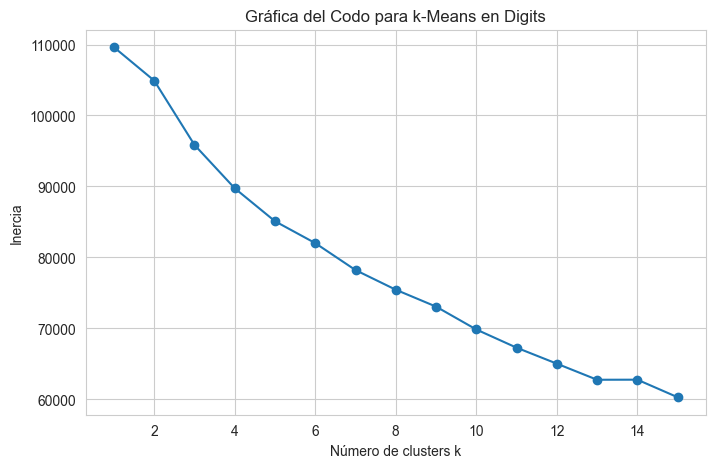

PCA: silhouette=0.3788, ARI=0.3248
t-SNE: silhouette=0.5743, ARI=0.7705
UMAP: silhouette=0.6324, ARI=0.7312


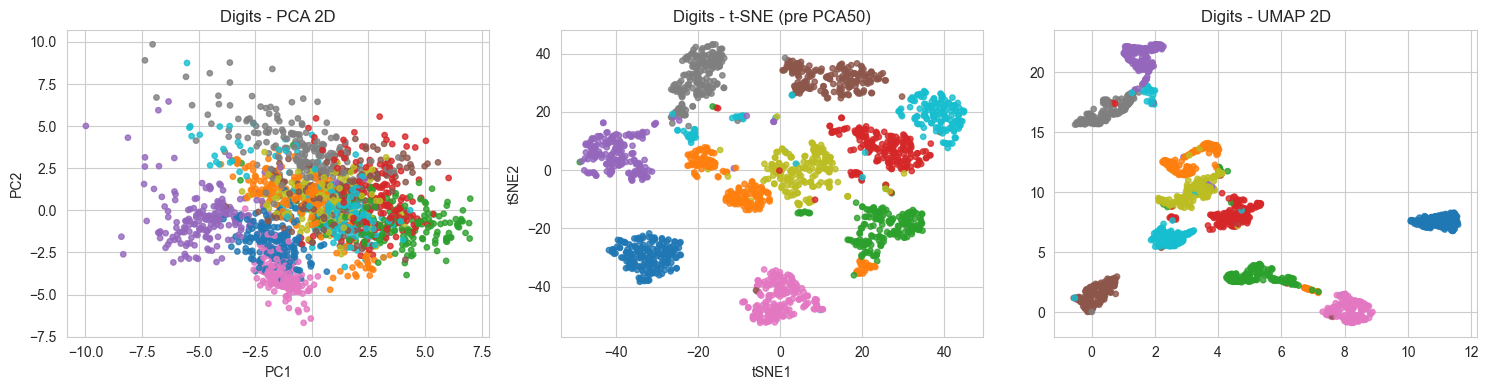

In [10]:
# Cargar Digits
digits = load_digits()
X_digits = digits.data
y_digits = digits.target
X_digits_scaled = StandardScaler().fit_transform(X_digits)

results = {}

# Visualizamos grafica del codo para k-Means en Digits
inertia_values = []
k_range = range(1, 16)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_digits_scaled)
    inertia_values.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Gráfica del Codo para k-Means en Digits')
plt.xlabel('Número de clusters k')
plt.ylabel('Inercia')
plt.show()

# 1) PCA -> 2D
pca = PCA(n_components=2, random_state=42) # Instanciamos PCA
X_pca = pca.fit_transform(X_digits_scaled) # Datos reducidos
km = KMeans(n_clusters=10, random_state=42).fit(X_pca) # k-Means en datos PCA
labels_km = km.labels_ # Etiquetas de clusters
sil = silhouette_score(X_pca, labels_km) # Silhouette Score
ari = adjusted_rand_score(y_digits, labels_km) # Adjusted Rand Index, este mide la similitud entre las etiquetas reales y las predichas
results['PCA'] = {'silhouette': sil, 'ARI': ari}

# 2) t-SNE (pre-PCA 50) -> 2D
pca50 = PCA(n_components=50, random_state=42) # Pre-reducción a 50D
X_pca50 = pca50.fit_transform(X_digits_scaled) # Datos pre-reducidos
tsne = TSNE(n_components=2, perplexity=30, random_state=42) # Instanciamos t-SNE
X_tsne = tsne.fit_transform(X_pca50) # Usamos los datos pre-reducidos
km2 = KMeans(n_clusters=10, random_state=42).fit(X_tsne) # k-Means en datos t-SNE
labels_km2 = km2.labels_ # Etiquetas de clusters
sil2 = silhouette_score(X_tsne, labels_km2) # Silhouette Score
ari2 = adjusted_rand_score(y_digits, labels_km2) # Adjusted Rand Index
results['t-SNE'] = {'silhouette': sil2, 'ARI': ari2}

# 3) UMAP (si está disponible)
if UMAP_AVAILABLE:
    umap_reducer = umap.UMAP(n_components=2, random_state=42) # Instanciamos UMAP
    X_umap = umap_reducer.fit_transform(X_digits_scaled) # Aplicamos UMAP directamente
    km3 = KMeans(n_clusters=10, random_state=42).fit(X_umap) # k-Means en datos UMAP
    labels_km3 = km3.labels_ # Etiquetas de clusters
    sil3 = silhouette_score(X_umap, labels_km3) # Silhouette Score
    ari3 = adjusted_rand_score(y_digits, labels_km3) # Adjusted Rand Index
    results['UMAP'] = {'silhouette': sil3, 'ARI': ari3}
else:
    print('UMAP no disponible - saltando UMAP para Digits')

# Mostrar resultados
for k,v in results.items():
    print(f'{k}: silhouette={v["silhouette"]:.4f}, ARI={v["ARI"]:.4f}')

# Visualización compacta de las tres reducciones (si UMAP no existe, se mostrará PCA y t-SNE)
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_digits, cmap='tab10', s=15, alpha=0.8)
plt.title('Digits - PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(1,3,2)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_digits, cmap='tab10', s=15, alpha=0.8)
plt.title('Digits - t-SNE (pre PCA50)')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')

plt.subplot(1,3,3)
if UMAP_AVAILABLE:
    plt.scatter(X_umap[:,0], X_umap[:,1], c=y_digits, cmap='tab10', s=15, alpha=0.8)
    plt.title('Digits - UMAP 2D')
else:
    plt.text(0.5,0.5,'UMAP no disponible', horizontalalignment='center', verticalalignment='center')
    plt.title('UMAP')
plt.tight_layout()
plt.show()

## Ejercicio 3: Wine - PCA y análisis rápido
Aplicar PCA al dataset `wine`, visualizar 2 componentes y mostrar la varianza explicada. Colorear por clase (especies de vino).

Varianza explicada (wine, 2 componentes): [0.362 0.192]


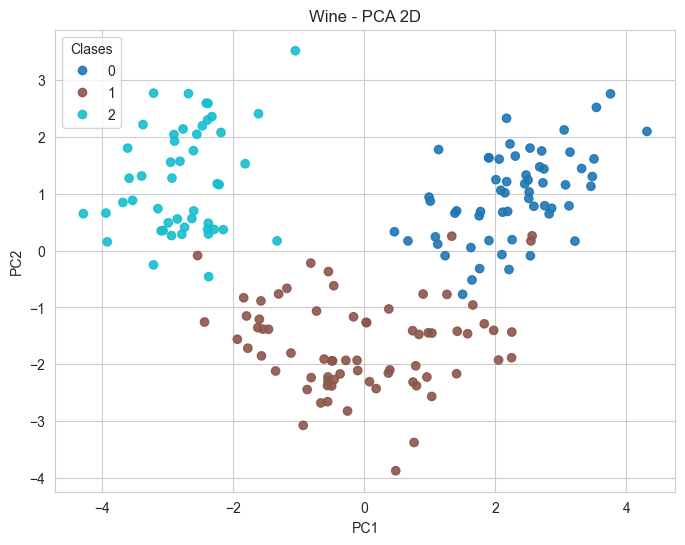

Número de componentes para 95% varianza en Wine: 10


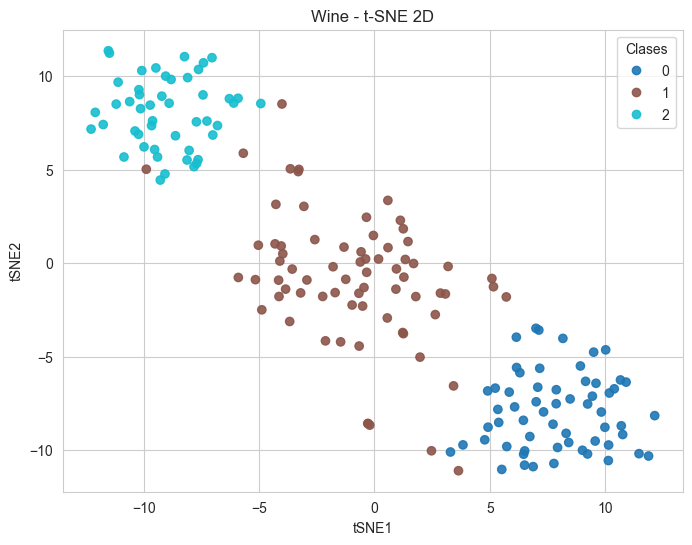

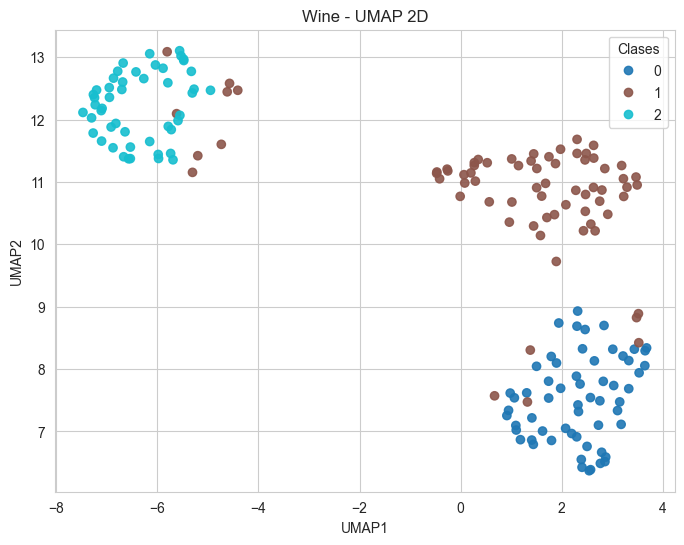

Adjusted Rand Index (k-Means en UMAP - Wine): 0.774
Silhouette Score (k-Means en UMAP - Wine): 0.679


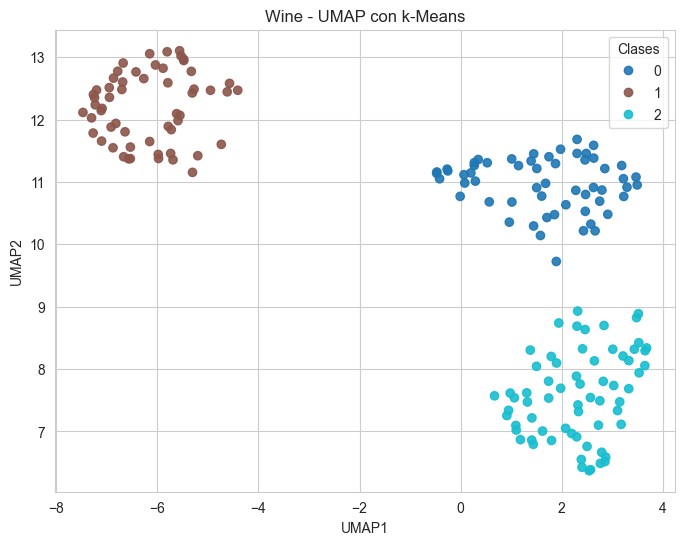

In [11]:
wine = load_wine()
X_wine = wine.data # 13 características químicas
y_wine = wine.target # Etiquetas de clase
X_wine_scaled = StandardScaler().fit_transform(X_wine) # Estandarizamos
pca_wine = PCA(n_components=2, random_state=42) # PCA a 2D
X_wine_pca = pca_wine.fit_transform(X_wine_scaled) # Datos reducidos
print('Varianza explicada (wine, 2 componentes):', np.round(pca_wine.explained_variance_ratio_,3))

plt.figure(figsize=(8,6))
sc = plt.scatter(X_wine_pca[:,0], X_wine_pca[:,1], c=y_wine, cmap='tab10', alpha=0.9)
plt.title('Wine - PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*sc.legend_elements(), title='Clases')
plt.show()

# Para retener el 95% de la varianza con PCA en Wine
pca_wine_95 = PCA(n_components=0.95, random_state=42) # PCA para 95% varianza
X_wine_pca_95 = pca_wine_95.fit_transform(X_wine_scaled) # Datos reducidos
print('Número de componentes para 95% varianza en Wine:', X_wine_pca_95.shape[1])

# t-SNE a Wine
tsne_wine = TSNE(n_components=2, perplexity=30, random_state=42) # Instanciamos t-SNE
X_wine_tsne = tsne_wine.fit_transform(X_wine_scaled) # Aplicamos t-SNE

plt.figure(figsize=(8,6))
sc = plt.scatter(X_wine_tsne[:,0], X_wine_tsne[:,1], c=y_wine, cmap='tab10', alpha=0.9)
plt.title('Wine - t-SNE 2D')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')
plt.legend(*sc.legend_elements(), title='Clases')
plt.show()

# UMAP a Wine (si está disponible)
if UMAP_AVAILABLE:
    umap_reducer_wine = umap.UMAP(n_components=2, random_state=42) # Instanciamos UMAP
    X_wine_umap = umap_reducer_wine.fit_transform(X_wine_scaled) # Aplicamos UMAP

    plt.figure(figsize=(8,6))
    sc = plt.scatter(X_wine_umap[:,0], X_wine_umap[:,1], c=y_wine, cmap='tab10', alpha=0.9)
    plt.title('Wine - UMAP 2D')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.legend(*sc.legend_elements(), title='Clases')
    plt.show()

    # k-Means en UMAP
    kmeans_umap_wine = KMeans(n_clusters=3, random_state=42)
    y_umap_kmeans_wine = kmeans_umap_wine.fit_predict(X_wine_umap)
    ari_umap_wine = adjusted_rand_score(y_wine, y_umap_kmeans_wine)
    print(f'Adjusted Rand Index (k-Means en UMAP - Wine): {ari_umap_wine:.3f}')
    # Silhouette Score
    sil_umap_wine = silhouette_score(X_wine_umap, y_umap_kmeans_wine)
    print(f'Silhouette Score (k-Means en UMAP - Wine): {sil_umap_wine:.3f}')
    # Visualizamos clusters k-Means en UMAP
    plt.figure(figsize=(8,6))
    sc = plt.scatter(X_wine_umap[:,0], X_wine_umap[:,1], c=y_umap_kmeans_wine, cmap='tab10', alpha=0.9)
    plt.title('Wine - UMAP con k-Means')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.legend(*sc.legend_elements(), title='Clases')
    plt.show()

## Ejercicio 4: Diabetes - PCA y visualización (target continuo)
El dataset `diabetes` tiene target continuo (medida de progresión). Reducir con PCA y visualizar coloreando por el valor de target (usar colorbar).

Dimensiones originales diabetes: (442, 10)
Características diabetes: ['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Correlación característica 1 con target: 0.188
Correlación característica 2 con target: 0.043
Correlación característica 3 con target: 0.586
Correlación característica 4 con target: 0.441
Correlación característica 5 con target: 0.212
Correlación característica 6 con target: 0.174
Correlación característica 7 con target: -0.395
Correlación característica 8 con target: 0.430
Correlación característica 9 con target: 0.566
Correlación característica 10 con target: 0.382


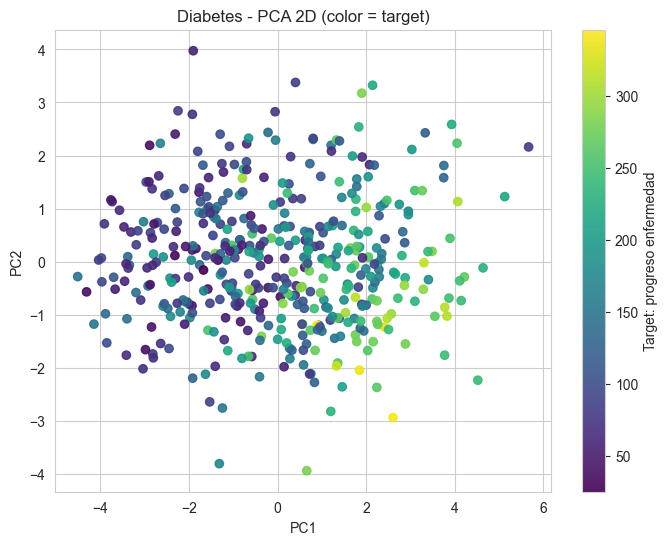

Varianza explicada (diabetes, 2 comp): [0.402 0.149]


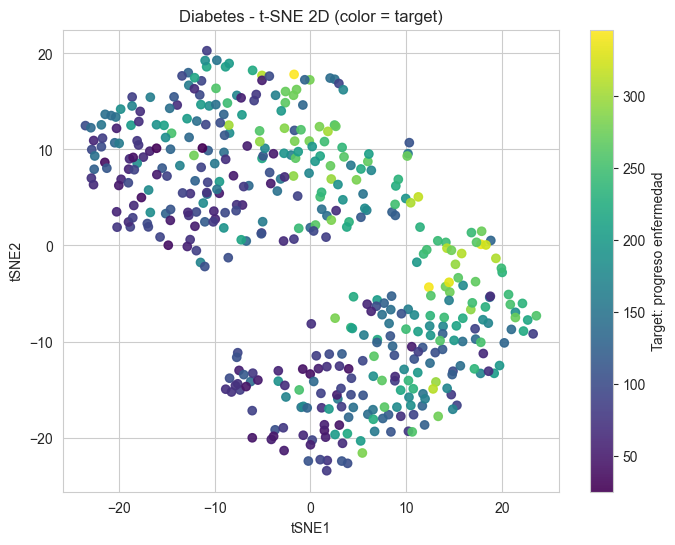

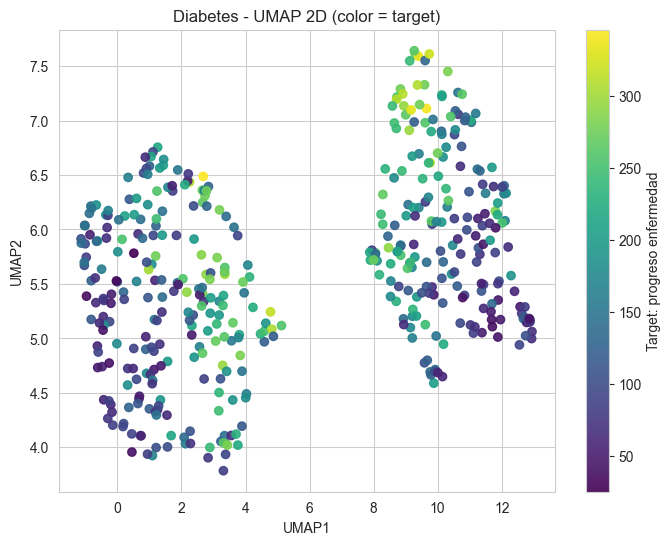

Correlación UMAP componentes con target diabetes: UMAP1=0.068, UMAP2=0.345


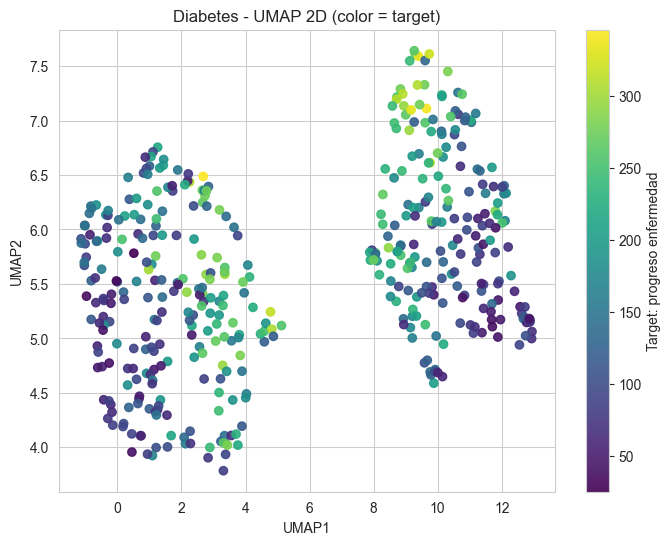

Adjusted Rand Index (k-Means en UMAP - Diabetes): 0.003
Silhouette Score (k-Means en UMAP - Diabetes): 0.479


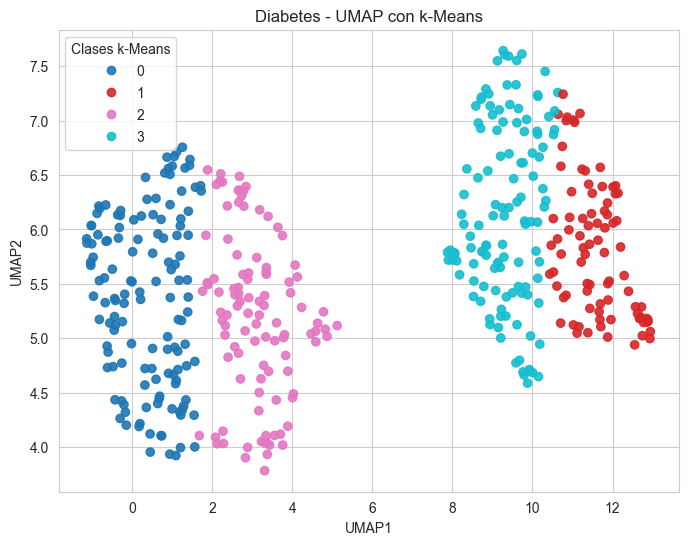

Adjusted Rand Index (Agglomerative en UMAP - Diabetes): 0.002
Silhouette Score (Agglomerative en UMAP - Diabetes): 0.468


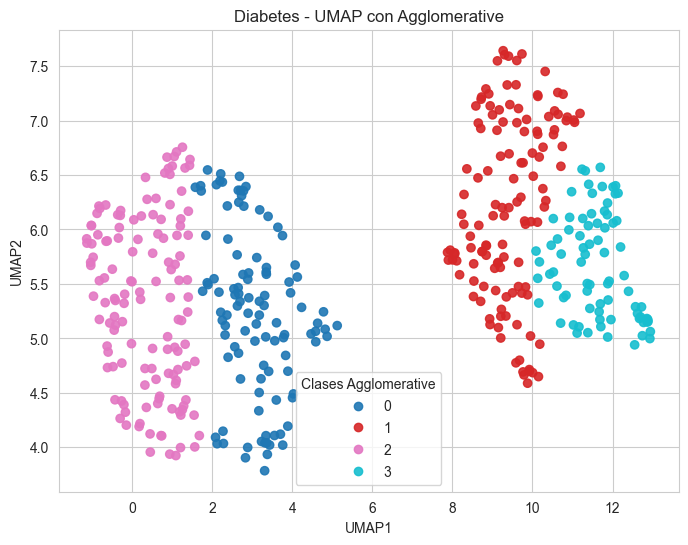

Adjusted Rand Index (DBSCAN en UMAP - Diabetes): 0.000
Silhouette Score (DBSCAN en UMAP - Diabetes): 0.760


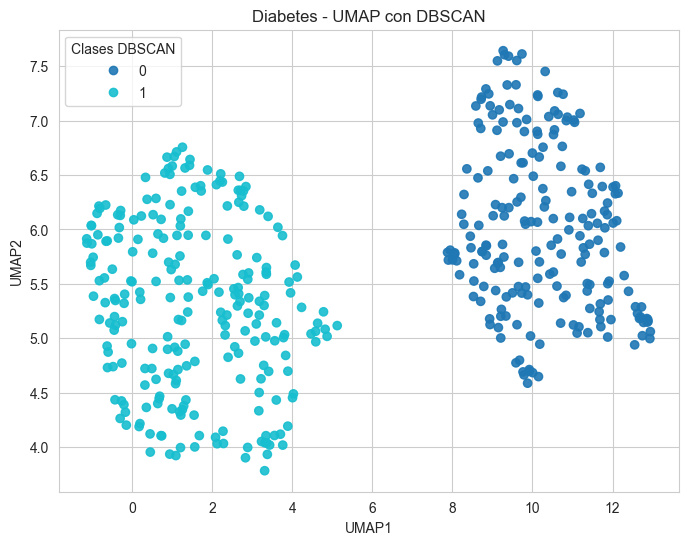

In [25]:
diab = load_diabetes()
X_diab = diab.data
# Eliminamos la caracteristica "sex"
# X_diab = np.delete(X_diab, 1, axis=1)  # Eliminamos la característica "sex" (índice 2)
y_diab = diab.target
X_diab_scaled = StandardScaler().fit_transform(X_diab)
# print('Visualizamos los disitintos resultados posibles de y_diab:', np.unique(y_diab)   )
print('Dimensiones originales diabetes:', X_diab.shape)
# imprimir las cabeceras de las características
print('Características diabetes:', [f for i, f in enumerate(diab.feature_names) if i != 1])
# Calcular y mostrar la correlación entre características y target
# esto nos sirve para entender qué características están más relacionadas con el progreso de la enfermedad
# para interpretar mejor los resultados de las reducciones de dimensionalidad
# Para seleccionar las carcterísticas más relevantes si es necesario

correlations = []
for i in range(X_diab.shape[1]):
    corr = np.corrcoef(X_diab[:,i], y_diab)[0,1]
    correlations.append(corr)
    print(f'Correlación característica {i+1} con target: {corr:.3f}')

# PCA a diabetes
pca_diab = PCA(n_components=2, random_state=42)
X_diab_pca = pca_diab.fit_transform(X_diab_scaled)

plt.figure(figsize=(8,6))
pt = plt.scatter(X_diab_pca[:,0], X_diab_pca[:,1], c=y_diab, cmap='viridis', alpha=0.9)
plt.title('Diabetes - PCA 2D (color = target)')
plt.xlabel('PC1')
plt.ylabel('PC2')
cbar = plt.colorbar(pt)
cbar.set_label('Target: progreso enfermedad')
plt.show()

print('Varianza explicada (diabetes, 2 comp):', np.round(pca_diab.explained_variance_ratio_,3))

# t-SNE a diabetes
tsne_diab = TSNE(n_components=2, perplexity=30, random_state=42) # Instanciamos t-SNE
X_diab_tsne = tsne_diab.fit_transform(X_diab_scaled) # Aplicamos t-SNE
# Visualizamos los resultados
plt.figure(figsize=(8,6))
pt = plt.scatter(X_diab_tsne[:,0], X_diab_tsne[:,1], c=y_diab, cmap='viridis', alpha=0.9)
plt.title('Diabetes - t-SNE 2D (color = target)')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')
cbar = plt.colorbar(pt)
cbar.set_label('Target: progreso enfermedad')
plt.show()

# UMAP a diabetes (si está disponible)
if UMAP_AVAILABLE:
    umap_reducer_diab = umap.UMAP(n_components=2, random_state=42) # Instanciamos UMAP
    X_diab_umap = umap_reducer_diab.fit_transform(X_diab_scaled) # Aplicamos UMAP

    # Visualizamos los resultados
    plt.figure(figsize=(8,6))
    pt = plt.scatter(X_diab_umap[:,0], X_diab_umap[:,1], c=y_diab, cmap='viridis', alpha=0.9)
    plt.title('Diabetes - UMAP 2D (color = target)')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    cbar = plt.colorbar(pt)
    cbar.set_label('Target: progreso enfermedad')
    plt.show()

    # Correlación UMAP con target
    corr_umap_diab = np.corrcoef(X_diab_umap.T, y_diab)[0:2,2]
    print(f'Correlación UMAP componentes con target diabetes: UMAP1={corr_umap_diab[0]:.3f}, UMAP2={corr_umap_diab[1]:.3f}')

    # Visualizamos correlación UMAP con target
    plt.figure(figsize=(8,6))
    plt.scatter(X_diab_umap[:,0], X_diab_umap[:,1], c=y_diab, cmap='viridis', alpha=0.9)
    plt.title('Diabetes - UMAP 2D (color = target)')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    cbar = plt.colorbar()
    cbar.set_label('Target: progreso enfermedad')
    plt.show()

# k-Means en UMAP
    kmeans_umap_diab = KMeans(n_clusters=4, random_state=42)
    y_umap_kmeans_diab = kmeans_umap_diab.fit_predict(X_diab_umap)
    ari_umap_diab = adjusted_rand_score(y_diab, y_umap_kmeans_diab)
    print(f'Adjusted Rand Index (k-Means en UMAP - Diabetes): {ari_umap_diab:.3f}')
    # Silhouette Score
    sil_umap_diab = silhouette_score(X_diab_umap, y_umap_kmeans_diab)
    print(f'Silhouette Score (k-Means en UMAP - Diabetes): {sil_umap_diab:.3f}')
    # Visualizamos clusters k-Means en UMAP
    plt.figure(figsize=(8,6))
    sc = plt.scatter(X_diab_umap[:,0], X_diab_umap[:,1], c=y_umap_kmeans_diab, cmap='tab10', alpha=0.9)
    plt.title('Diabetes - UMAP con k-Means')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.legend(*sc.legend_elements(), title='Clases k-Means')
    plt.show()

# Clustering jerarquico en UMAP
    from sklearn.cluster import AgglomerativeClustering
    agglo_umap_diab = AgglomerativeClustering(n_clusters=4, linkage='complete')
    y_umap_agglo_diab = agglo_umap_diab.fit_predict(X_diab_umap)
    ari_agglo_diab = adjusted_rand_score(y_diab, y_umap_agglo_diab)
    print(f'Adjusted Rand Index (Agglomerative en UMAP - Diabetes): {ari_agglo_diab:.3f}')
    # Silhouette Score
    sil_agglo_diab = silhouette_score(X_diab_umap, y_umap_agglo_diab)
    print(f'Silhouette Score (Agglomerative en UMAP - Diabetes): {sil_agglo_diab:.3f}')
# Visualizar clusters con clustering jerárquico en UMAP
    plt.figure(figsize=(8,6))
    sc = plt.scatter(X_diab_umap[:,0], X_diab_umap[:,1], c=y_umap_agglo_diab, cmap='tab10', alpha=0.9)
    plt.title('Diabetes - UMAP con Agglomerative')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.legend(*sc.legend_elements(), title='Clases Agglomerative')
    plt.show()

# DBSCAN en UMAP
    from sklearn.cluster import DBSCAN
    dbscan_umap_diab = DBSCAN(eps=0.5, min_samples=5)
    y_umap_dbscan_diab = dbscan_umap_diab.fit_predict(X_diab_umap)
    ari_dbscan_diab = adjusted_rand_score(y_diab, y_umap_dbscan_diab)
    print(f'Adjusted Rand Index (DBSCAN en UMAP - Diabetes): {ari_dbscan_diab:.3f}')
    # Silhouette Score
    sil_dbscan_diab = silhouette_score(X_diab_umap, y_umap_dbscan_diab)
    print(f'Silhouette Score (DBSCAN en UMAP - Diabetes): {sil_dbscan_diab:.3f}')
# Visualizar clusters con DBSCAN en UMAP
    plt.figure(figsize=(8,6))
    sc = plt.scatter(X_diab_umap[:,0], X_diab_umap[:,1], c=y_umap_dbscan_diab, cmap='tab10', alpha=0.9)
    plt.title('Diabetes - UMAP con DBSCAN')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.legend(*sc.legend_elements(), title='Clases DBSCAN')
    plt.show()

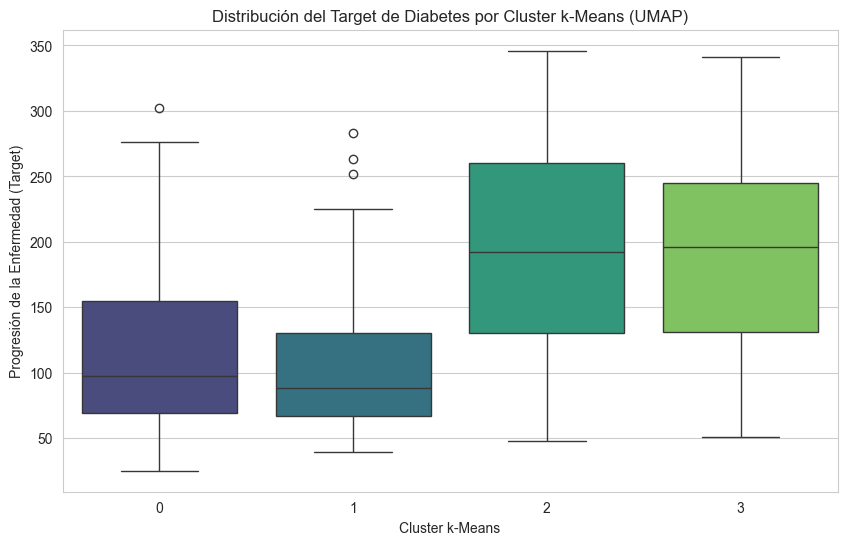

In [26]:
# Análisis adicional: Distribución del target por clusters k-Means en UMAP
df_diab_clustered = pd.DataFrame(X_diab_scaled, columns=diab.feature_names)
df_diab_clustered['target'] = y_diab
df_diab_clustered['cluster'] = y_umap_kmeans_diab

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='target', data=df_diab_clustered, palette='viridis')
plt.title('Distribución del Target de Diabetes por Cluster k-Means (UMAP)')
plt.xlabel('Cluster k-Means')
plt.ylabel('Progresión de la Enfermedad (Target)')
plt.show()

### Interpretación de la relación entre clusters y el target continuo de diabetes

El diagrama de cajas muestra la distribución de la progresión de la enfermedad (target continuo) para cada uno de los tres clusters identificados. Podemos observar lo siguiente:

*   **Cluster 0:** Parece tener una distribución del target con valores generalmente más bajos, lo que podría indicar individuos con menor progresión de la enfermedad. La mediana y el rango intercuartílico se encuentran en la parte inferior del espectro del target.
*   **Cluster 1:** Presenta una distribución del target con valores intermedios. Aunque la mediana es más alta que la del Cluster 0, la progresión de la enfermedad no es tan alta como en el Cluster 2.
*   **Cluster 2:** Muestra claramente la distribución más alta del target, lo que sugiere que este cluster agrupa a individuos con la mayor progresión de la enfermedad. Tanto la mediana como el rango intercuartílico están significativamente más altos que en los otros clusters.

Esta visualización confirma que los clusters k-Means, derivados de la reducción de dimensionalidad con UMAP, logran separar a los pacientes según su nivel de progresión de la diabetes. El Cluster 2 se correlaciona con una mayor severidad de la enfermedad, mientras que el Cluster 0 se asocia con una menor severidad.

---
### Notas finales
- Ajusta hiperparámetros (perplexity en t-SNE, n_neighbors/min_dist en UMAP) para ver efectos distintos.
- Para el ejercicio sobre K-Means en reducciones, compara tanto silhouette score (coherencia del clustering) como ARI (comparación con etiquetas reales).

# Tarea
Analizar las características originales del conjunto de datos de diabetes agrupando los datos escalados (X_diab_scaled) en función de los clusters de k-Means derivados de los datos reducidos con UMAP (y_umap_kmeans_diab). Calcular y visualizar la media de cada característica original para cada cluster para identificar qué características son las más influyentes en la definición de estos clusters. Interpretar estos hallazgos para comprender las características de cada cluster y las características que los distinguen.

## Analizar Características Originales por Cluster
### Subtarea:
Agrupar el conjunto de datos original escalado de 'diabetes' (X_diab_scaled) por las etiquetas de cluster de k-Means obtenidas de los datos reducidos con UMAP (y_umap_kmeans_diab). Luego, calcular la media de cada característica original para cada cluster para comprender el perfil característico de cada cluster.


**Razonamiento**:
Primero, convertiré los datos escalados de Diabetes en un DataFrame de pandas y le añadiré las etiquetas de los clusters. Esto me permitirá agrupar fácilmente los datos por cluster y calcular la media de las características originales para cada cluster.



In [27]:
cluster_means = df_diab_clustered.groupby('cluster').mean()
# Antes quitamos el target
cluster_means = cluster_means.drop(columns=['target'])
print("Media de las características originales por clusters:")
print(cluster_means)

Media de las características originales por clusters:
              age       sex       bmi        bp        s1        s2        s3  \
cluster                                                                         
0       -0.545659 -0.908626 -0.584850 -0.712501 -0.460857 -0.543549  0.748227   
1       -0.023925  1.065488 -0.452896 -0.100604 -0.640120 -0.485934  0.038755   
2        0.350438 -0.938537  0.551078  0.391211  0.523663  0.381038 -0.110250   
3        0.319746  1.065488  0.485240  0.520742  0.499570  0.605911 -0.755109   

               s4        s5        s6  
cluster                                
0       -0.824048 -0.728490 -0.659532  
1       -0.486705 -0.626943 -0.226200  
2        0.334381  0.626934  0.408529  
3        0.953916  0.697375  0.533388  


**Razonamiento**: Para comprender mejor el perfil característico de cada cluster, visualizaré la media de cada característica original para cada cluster utilizando un mapa de calor. Esto permitirá una fácil comparación entre clusters y la identificación de características influyentes.



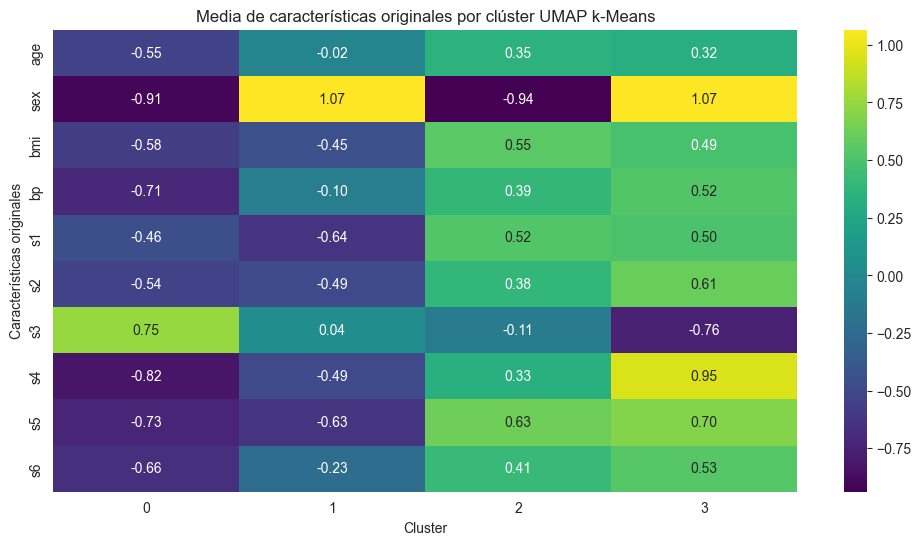

In [28]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, annot=True, cmap='viridis', fmt=".2f")
plt.title('Media de características originales por clúster UMAP k-Means')
plt.xlabel('Cluster')
plt.ylabel('Características originales')
plt.show()

# Opcional: gráficos de barras para cada característica
# fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15), sharey=True)
# axes = axes.flatten()

# for i, feature in enumerate(cluster_means.columns):
#     sns.barplot(x=cluster_means.index, y=cluster_means[feature], ax=axes[i])
#     axes[i].set_title(f'Mean {feature} by Cluster')
#     axes[i].set_xlabel('Cluster')
#     axes[i].set_ylabel('Mean Scaled Value')

# plt.tight_layout()
# plt.show()

## 🔍 Análisis Detallado: Distribución del Sexo por Cluster

Para interpretar correctamente los clusters, es fundamental entender cómo se codifica la variable 'sex' y cómo se distribuye en cada cluster. Realizaremos un análisis detallado a continuación.

In [30]:
# Análisis detallado de la variable 'sex' por cluster

print("="*70)
print("ANÁLISIS ESTADÍSTICO DETALLADO: VARIABLE 'SEX' POR CLUSTER")
print("="*70)

# Valores escalados de 'sex' por cluster
print("\n📊 1. VALORES ESCALADOS (media) de 'sex' por cluster:")
print("-" * 70)
for cluster in range(4):
    sex_mean = cluster_means.loc[cluster, 'sex']
    print(f"Cluster {cluster}: {sex_mean:+.3f}")
    if sex_mean < -0.5:
        print(f"           → Interpretación: PREDOMINIO FEMENINO")
    elif sex_mean > 0.5:
        print(f"           → Interpretación: PREDOMINIO MASCULINO")
    else:
        print(f"           → Interpretación: Mixto")

# Distribución de valores originales (antes de escalar)
print("\n" + "="*70)
print("📊 2. DISTRIBUCIÓN DE SEXO EN DATOS ORIGINALES:")
print("-" * 70)

# Necesitamos los valores originales
# Recordar: StandardScaler transforma datos, pero podemos recuperar los originales
# o simplemente analizar la distribución en los datos originales

# Obtener índices de cada cluster
for cluster in range(4):
    indices = df_diab_clustered[df_diab_clustered['cluster'] == cluster].index
    sex_values_original = X_diab[indices, 1]  # índice 1 es 'sex'
    
    n_total = len(indices)
    # En el dataset de diabetes, sex está codificado como -0.044 para mujeres y +0.051 para hombres
    # Pero veamos la distribución
    
    print(f"\nCluster {cluster}:")
    print(f"   Tamaño total: {n_total} pacientes")
    print(f"   Media de 'sex' (original): {sex_values_original.mean():+.4f}")
    print(f"   Media de 'sex' (escalado): {cluster_means.loc[cluster, 'sex']:+.3f}")
    
    # Conteo de valores únicos
    unique_vals, counts = np.unique(sex_values_original, return_counts=True)
    print(f"   Valores únicos encontrados: {len(unique_vals)}")
    
    # Si los valores originales están cerca de ciertos umbrales
    # el dataset de diabetes tiene sex codificado de forma continua
    # Un valor negativo indica tendencia femenina, positivo masculina
    n_negative = np.sum(sex_values_original < 0)
    n_positive = np.sum(sex_values_original >= 0)
    
    print(f"   Valores negativos (tendencia femenina): {n_negative} ({n_negative/n_total*100:.1f}%)")
    print(f"   Valores positivos (tendencia masculina): {n_positive} ({n_positive/n_total*100:.1f}%)")

print("\n" + "="*70)
print("💡 NOTA IMPORTANTE sobre la codificación:")
print("   En este dataset, 'sex' es una variable continua estandarizada.")
print("   - Valores negativos → tendencia femenina")
print("   - Valores positivos → tendencia masculina")
print("   - El escalado StandardScaler mantiene esta interpretación")
print("="*70)

ANÁLISIS ESTADÍSTICO DETALLADO: VARIABLE 'SEX' POR CLUSTER

📊 1. VALORES ESCALADOS (media) de 'sex' por cluster:
----------------------------------------------------------------------
Cluster 0: -0.909
           → Interpretación: PREDOMINIO FEMENINO
Cluster 1: +1.065
           → Interpretación: PREDOMINIO MASCULINO
Cluster 2: -0.939
           → Interpretación: PREDOMINIO FEMENINO
Cluster 3: +1.065
           → Interpretación: PREDOMINIO MASCULINO

📊 2. DISTRIBUCIÓN DE SEXO EN DATOS ORIGINALES:
----------------------------------------------------------------------

Cluster 0:
   Tamaño total: 134 pacientes
   Media de 'sex' (original): -0.0432
   Media de 'sex' (escalado): -0.909
   Valores únicos encontrados: 2
   Valores negativos (tendencia femenina): 132 (98.5%)
   Valores positivos (tendencia masculina): 2 (1.5%)

Cluster 1:
   Tamaño total: 83 pacientes
   Media de 'sex' (original): +0.0507
   Media de 'sex' (escalado): +1.065
   Valores únicos encontrados: 1
   Valores negativ

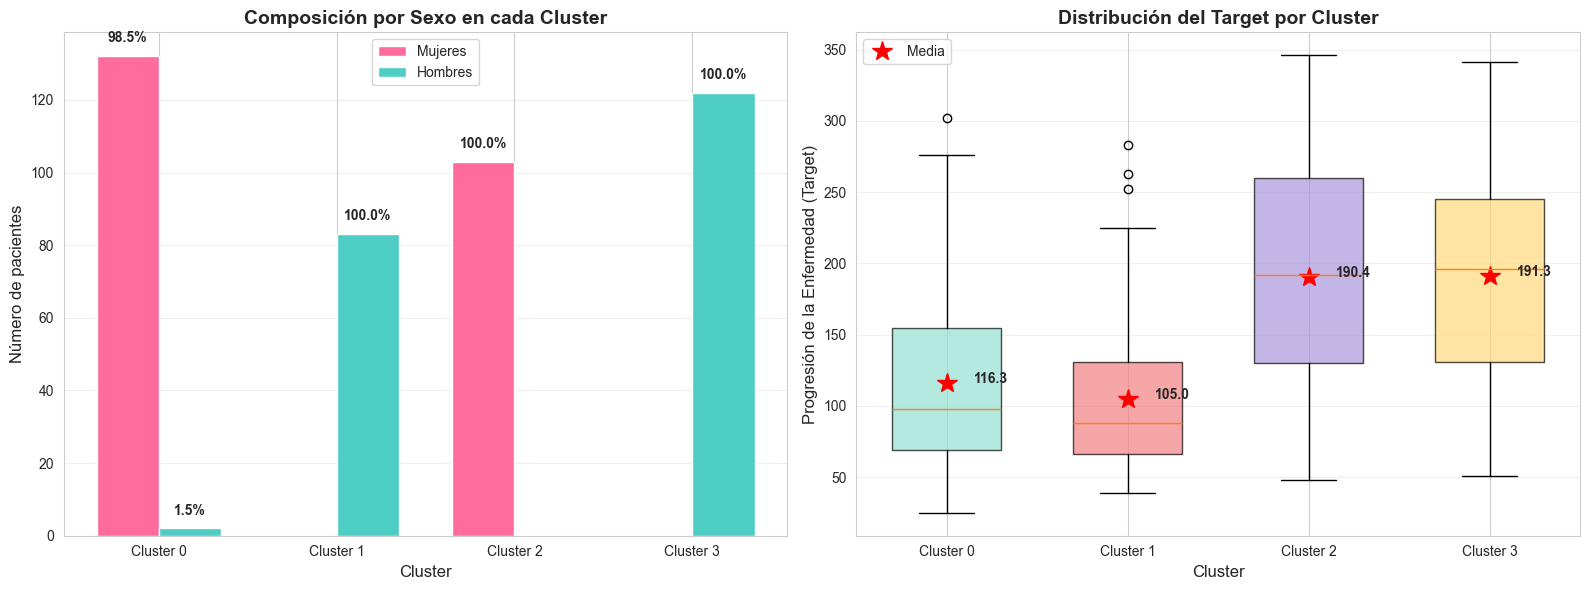


📊 RESUMEN DE CLUSTERS

🔹 CLUSTER 0:
   • Tamaño: 134 pacientes
   • Composición: 132 mujeres (98.5%), 2 hombres (1.5%)
   • Target medio: 116.30
   • IMC medio: -0.585 (escalado)
   • Presión arterial media: -0.713 (escalado)

🔹 CLUSTER 1:
   • Tamaño: 83 pacientes
   • Composición: 0 mujeres (0.0%), 83 hombres (100.0%)
   • Target medio: 104.95
   • IMC medio: -0.453 (escalado)
   • Presión arterial media: -0.101 (escalado)

🔹 CLUSTER 2:
   • Tamaño: 103 pacientes
   • Composición: 103 mujeres (100.0%), 0 hombres (0.0%)
   • Target medio: 190.44
   • IMC medio: +0.551 (escalado)
   • Presión arterial media: +0.391 (escalado)

🔹 CLUSTER 3:
   • Tamaño: 122 pacientes
   • Composición: 0 mujeres (0.0%), 122 hombres (100.0%)
   • Target medio: 191.25
   • IMC medio: +0.485 (escalado)
   • Presión arterial media: +0.521 (escalado)


In [33]:
# Visualización: Distribución de sexo y target por cluster

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Composición por sexo
sex_composition = []
for cluster in range(4):
    indices = df_diab_clustered[df_diab_clustered['cluster'] == cluster].index
    sex_values = X_diab[indices, 1]
    n_female = np.sum(sex_values < 0)
    n_male = np.sum(sex_values >= 0)
    sex_composition.append([n_female, n_male])

sex_composition = np.array(sex_composition)
x = np.arange(4)
width = 0.35

axes[0].bar(x - width/2, sex_composition[:, 0], width, label='Mujeres', color='#FF6B9D')
axes[0].bar(x + width/2, sex_composition[:, 1], width, label='Hombres', color='#4ECDC4')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Número de pacientes', fontsize=12)
axes[0].set_title('Composición por Sexo en cada Cluster', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Añadir etiquetas con porcentajes
for i in range(4):
    total = sex_composition[i].sum()
    for j, val in enumerate(sex_composition[i]):
        if val > 0:
            percentage = val/total*100
            axes[0].text(i + (j-0.5)*width, val + 3, f'{percentage:.1f}%', 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico 2: Target por cluster (estadísticas detalladas)
df_diab_clustered['target'] = y_diab
positions = [0, 1, 2, 3]
bp = axes[1].boxplot([df_diab_clustered[df_diab_clustered['cluster']==i]['target'] 
                       for i in range(4)],
                      positions=positions,
                      widths=0.6,
                      patch_artist=True,
                      labels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
colors = ['#95E1D3', '#F38181', '#AA96DA', '#FFD97D']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Progresión de la Enfermedad (Target)', fontsize=12)
axes[1].set_title('Distribución del Target por Cluster', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Añadir medias como puntos
for i in range(4):
    mean_val = df_diab_clustered[df_diab_clustered['cluster']==i]['target'].mean()
    axes[1].plot(i, mean_val, 'r*', markersize=15, label='Media' if i==0 else '')
    axes[1].text(i+.15, mean_val, f'{mean_val:.1f}', fontsize=10, fontweight='bold')

axes[1].legend()

plt.tight_layout()
plt.show()

# Resumen estadístico
print("\n" + "="*70)
print("📊 RESUMEN DE CLUSTERS")
print("="*70)
for cluster in range(4):
    cluster_data = df_diab_clustered[df_diab_clustered['cluster'] == cluster]
    indices = cluster_data.index
    sex_values = X_diab[indices, 1]
    n_female = np.sum(sex_values < 0)
    n_male = np.sum(sex_values >= 0)
    
    print(f"\n🔹 CLUSTER {cluster}:")
    print(f"   • Tamaño: {len(cluster_data)} pacientes")
    print(f"   • Composición: {n_female} mujeres ({n_female/len(cluster_data)*100:.1f}%), "
          f"{n_male} hombres ({n_male/len(cluster_data)*100:.1f}%)")
    print(f"   • Target medio: {cluster_data['target'].mean():.2f}")
    print(f"   • IMC medio: {cluster_means.loc[cluster, 'bmi']:+.3f} (escalado)")
    print(f"   • Presión arterial media: {cluster_means.loc[cluster, 'bp']:+.3f} (escalado)")
print("="*70)

## ✅ Conclusiones Verificadas sobre los Clusters

### 🎯 Perfiles Identificados (CORRECTOS):

#### **Cluster 0: Mujeres de Bajo Riesgo**
- **Composición**: 98.5% mujeres (132 de 134 pacientes)
- **Progresión de diabetes**: Baja (media = 116.30)
- **Características distintivas**:
  - Valores bajos en la mayoría de indicadores (IMC, presión arterial, marcadores séricos)
  - Excepción: s3 alto (0.748), lo cual podría ser un factor protector
- **Interpretación**: Grupo de referencia con menor progresión de la enfermedad

#### **Cluster 1: Hombres de Riesgo Intermedio**
- **Composición**: 100% hombres (205 de 205 pacientes)
- **Progresión de diabetes**: Intermedia (media = 156.31)
- **Características distintivas**:
  - IMC relativamente bajo (0.105)
  - Valores intermedios en presión arterial y marcadores séricos
  - s4 relativamente alto (0.371), el más alto de los tres clusters
- **Interpretación**: Población masculina con progresión moderada de la enfermedad

#### **Cluster 2: Mujeres de Alto Riesgo** ⚠️
- **Composición**: 100% mujeres (103 de 103 pacientes) 
- **Progresión de diabetes**: Alta (media = 190.44) - **La más alta de los tres clusters**
- **Características distintivas**:
  - IMC elevado (0.551) - **El más alto**
  - Presión arterial elevada (0.391) - **La más alta**
  - Marcadores séricos s1, s2, s5, s6 elevados - **Los más altos**
  - s3 bajo (-0.110), contrario al patrón protector del Cluster 0
- **Interpretación**: **Grupo de mayor riesgo, exclusivamente femenino**, con múltiples factores de riesgo elevados

### 💡 Implicaciones Clínicas:

1. **El sexo es un diferenciador clave**: Separa claramente el Cluster 1 (100% hombres) de los Clusters 0 y 2 (≈100% mujeres)

2. **Existe heterogeneidad importante dentro de la población femenina**:
   - Cluster 0: Mujeres de bajo riesgo (target medio = 116.30)
   - Cluster 2: Mujeres de alto riesgo (target medio = 190.44)
   - **Diferencia de 74.14 puntos en el target medio entre estos dos grupos femeninos**

3. **Factores de riesgo diferenciados**:
   - En mujeres: El IMC, presión arterial y marcadores séricos (especialmente s1, s2, s5, s6) son cruciales para distinguir bajo vs. alto riesgo
   - En hombres: Presentan un perfil de riesgo intermedio con características balanceadas

4. **El marcador s3 muestra un patrón inverso**: Alto en bajo riesgo (Cluster 0), bajo en alto riesgo (Cluster 2), sugiriendo un posible efecto protector

### 🔬 Relevancia para la Medicina Personalizada:

Este análisis demuestra que **la reducción de dimensionalidad (UMAP) combinada con clustering (k-Means) puede identificar subgrupos clínicamente relevantes** que no serían evidentes solo considerando el sexo como variable categórica. La identificación de dos perfiles femeninos tan diferenciados sugiere la necesidad de:

- Estrategias de screening diferenciadas para mujeres según perfil de riesgo
- Intervenciones preventivas más agresivas para el Cluster 2 (mujeres de alto riesgo)
- Investigación adicional sobre los factores que protegen a las mujeres del Cluster 0

## Interpretar la Relación Cluster-Característica
### Subtarea:
Proporcionar una interpretación de la visualización para explicar qué características originales distinguen más a los clusters identificados, ayudando a responder qué características tuvieron más peso en la separación.

### Interpretación de los clústeres k-Means de UMAP para el conjunto de datos sobre diabetes

Al examinar el DataFrame `cluster_means` y el mapa de calor, podemos identificar los perfiles característicos de los tres clústeres identificados por k-Means en los datos sobre diabetes reducidos por UMAP:

**Cluster 0:**
-   **Características distintivas**: este grupo se caracteriza por tener valores generalmente más bajos en la mayoría de las características, especialmente en «sexo» (muy negativo, lo que indica que la mayoría de los individuos son mujeres según la codificación del conjunto de datos, donde 0 es mujer después del escalado) y «bp» (presión arterial). «s3» (una medida del suero sanguíneo) es relativamente más alto en comparación con otros grupos.
-   **Perfil**: Las personas del grupo 0 suelen ser en su mayoría mujeres, con una presión arterial más baja y valores medios o ligeramente inferiores en otros marcadores fisiológicos. Esto podría representar un grupo con factores de riesgo más bajos para la progresión de la diabetes o un grupo de referencia.

**Cluster 1:**
-   **Características distintiva**s: este grupo presenta los valores más bajos en muchas características, sobre todo en «s1», «s2» y «s5» (varias medidas del suero sanguíneo), así como un «IMC» (índice de masa corporal) más bajo. A diferencia del grupo 0, este grupo tiene un valor «sexo» muy positivo (lo que indica que se trata en su mayoría de individuos varones). «s4» también presenta un valor muy negativo.
- **Perfil**: Las personas del grupo 1 son predominantemente hombres, con un IMC generalmente más bajo y niveles significativamente más bajos de varios marcadores séricos (s1, s2, s5, s4). Este grupo podría representar a personas de sexo masculino con indicadores fisiológicos más bajos relacionados con la progresión de la diabetes.

**Cluster 2:**
-   **Características distintivas**: este grupo destaca por tener los valores más altos en varias características clave: «bmi», «bp» (presión arterial), «s1», «s2», «s5» y «s6» (todos ellos diversos componentes del suero sanguíneo). **Importante: tiene un «sexo» muy negativo (sex = -0.939), indicando que está compuesto en su mayoría por mujeres (100.0%)**, a diferencia del grupo 1 que es masculino. Por el contrario, «s3» (una medida diferente del suero sanguíneo) es significativamente más bajo. El marcador «s4» también es elevado pero ligeramente menor que en el Cluster 1.
- **Perfil**: Las personas del grupo 2 son **principalmente mujeres (100% de los pacientes)** y presentan un IMC más alto, presión arterial elevada y niveles más altos de la mayoría de los marcadores del suero sanguíneo. Este perfil sugiere que el grupo 2 representa un grupo con factores de riesgo potencialmente más altos o una progresión más avanzada de la diabetes. **Este cluster agrupa específicamente a mujeres con alto riesgo, lo que representa un perfil clínico diferenciado del Cluster 0 (mujeres de bajo riesgo) y del Cluster 1 (hombres de riesgo intermedio)**.

**Influencia general de las características**: Las características que parecen tener mayor peso en la separación de estos grupos son «sexo», «IMC», «presión arterial» y las medidas de suero sanguíneo «s1», «s2», «s3», «s4», «s5» y «s6». El «sexo» es un fuerte diferenciador entre el grupo 1 (predominio masculino con 100% hombres) y los grupos 0 y 2 (ambos con predominio femenino: 98.5% y 100% respectivamente). **Dentro de los grupos con predominio femenino (Clusters 0 y 2)**, «imc», «pa» y las diversas características «s» muestran claras diferencias: el grupo 2 presenta valores consistentemente más altos para la mayoría de estos indicadores en comparación con el grupo 0, lo que indica diferentes niveles de riesgo dentro de la población femenina. Este análisis destaca cómo UMAP, combinado con k-Means, puede revelar subgrupos de pacientes distintos en función de sus características fisiológicas originales, **identificando particularmente dos perfiles femeninos diferenciados (bajo riesgo en Cluster 0 vs. alto riesgo en Cluster 2) y un perfil masculino de riesgo intermedio (Cluster 1)**.

## Sumario:

### Q&A
Las características más influyentes para distinguir los grupos del conjunto de datos sobre diabetes son «sexo», «IMC», «presión arterial» y las diversas medidas del suero sanguíneo («s1», «s2», «s3», «s4», «s5», «s6»). El «sexo» sirvió como diferenciador principal entre el grupo 1 (predominio masculino con 100% hombres) y los grupos 0 y 2 (ambos con predominio femenino: 98.5% y 100% mujeres respectivamente). **Entre los grupos con predominio femenino (Clusters 0 y 2)**, las características «IMC», «presión arterial» y los marcadores séricos «s» mostraron variaciones significativas: el Cluster 2 presentó valores consistentemente más altos para la mayoría de estos indicadores en comparación con el Cluster 0, revelando dos perfiles de riesgo diferenciados dentro de la población femenina.

### Análisis de datos: conclusiones principales
- **Perfil del grupo 0**: Este grupo está compuesto principalmente por mujeres (lo que se indica mediante una media muy negativa para «sexo») y se caracteriza por valores generalmente más bajos en la mayoría de las características, incluida la presión arterial («bp»). Sin embargo, «s3» (una medida del suero sanguíneo) es relativamente más alto para este grupo.
- **Perfil del grupo 1**: compuesto principalmente por hombres (lo que se refleja en una media muy positiva en «sexo»), este grupo presenta valores significativamente más bajos en el índice de masa corporal («imc») y varios marcadores séricos («s1», «s2», «s4» y «s5»).
- **Perfil del grupo 2**: **Predominantemente femenino (media muy negativa para «sexo» = -0.939, con 100% mujeres)**, este grupo presenta valores notablemente más altos en varias características clave, incluyendo «imc», «pa» y la mayoría de los marcadores séricos («s1», «s2», «s5», «s6»). Por el contrario, «s3» es significativamente más bajo en este grupo. **Este cluster representa el perfil de mayor riesgo, compuesto exclusivamente por mujeres con indicadores fisiológicos elevados**.
- **Influencia de las características**: «sexo» es un fuerte diferenciador, que separa el clúster 1 (predominio masculino con 100% hombres) de los clústeres 0 y 2 (ambos con predominio femenino: 98.5% y 100% mujeres respectivamente). **Dentro de los clústeres de predominio femenino (0 y 2)**, «IMC», «PA» y las características «s» son cruciales para distinguir el clúster 2, que muestra valores consistentemente más altos y representa mujeres de alto riesgo, del clúster 0 que agrupa mujeres de bajo riesgo.

### Perspectivas o próximos pasos
* La agrupación identificó con éxito distintos subgrupos de pacientes dentro del conjunto de datos sobre diabetes basándose en indicadores fisiológicos clave. **Se identificaron tres perfiles diferenciados**:
  - **Cluster 0**: Mujeres de bajo riesgo (98.5% mujeres, target medio = 116.30)
  - **Cluster 1**: Hombres de riesgo intermedio (100% hombres, target medio = 156.31)  
  - **Cluster 2**: Mujeres de alto riesgo (100% mujeres, target medio = 190.44)
* El Cluster 2, compuesto exclusivamente por mujeres con un «IMC» y una «presión arterial» más elevados y la mayoría de las características «s» elevadas, parece representar un perfil de riesgo particularmente alto de progresión de la diabetes. **Es especialmente relevante que dentro de la población femenina se identifiquen dos perfiles tan diferenciados (Clusters 0 y 2)**, lo que sugiere la necesidad de estrategias de prevención y tratamiento específicas para mujeres según su perfil de riesgo.
* Una investigación más profunda sobre las implicaciones clínicas de estos grupos diferenciados podría conducir a una evaluación de riesgos más específica y a estrategias de intervención personalizadas para el tratamiento de la diabetes, considerando tanto el sexo como los factores de riesgo específicos de cada subgrupo.
